In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Understanding the Raw Data

In [2]:
df = pd.read_excel('../../data/raw/unicef/Bacillus Calmette–Guérin (BCG) vaccination coverage 2026-11-03 15-22 UTC.xlsx')
print('--------------------------------------------------------------')
print('Checking values of the table head')
print('--------------------------------------------------------------')
print(df.head())

print()
print('-------------------------------------')
print('File Shape')
print('-------------------------------------')
print(df.shape)

--------------------------------------------------------------
Checking values of the table head
--------------------------------------------------------------
       GROUP CODE         NAME    YEAR ANTIGEN ANTIGEN_DESCRIPTION  \
0  COUNTRIES  AFG  Afghanistan  2024.0     BCG                 BCG   
1  COUNTRIES  ALB      Albania  2024.0     BCG                 BCG   
2  COUNTRIES  DZA      Algeria  2024.0     BCG                 BCG   
3  COUNTRIES  AND      Andorra  2024.0     BCG                 BCG   
4  COUNTRIES  AGO       Angola  2024.0     BCG                 BCG   

  COVERAGE_CATEGORY COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER      DOSES  \
0             ADMIN       Administrative coverage      2002760.0  1929249.0   
1             ADMIN       Administrative coverage        22007.0    21780.0   
2             ADMIN       Administrative coverage       873178.0   858780.0   
3             ADMIN       Administrative coverage            NaN        NaN   
4             ADMIN     

In [3]:
print('-------------------------------------')
print('Check for Column data Types')
print('-------------------------------------')
print(df.dtypes)
print()
print()
print('--------------------------------------')
print('Check for NULL Values on each column')
print('-------------------------------------')
print(df.isnull().sum())

-------------------------------------
Check for Column data Types
-------------------------------------
GROUP                                str
CODE                                 str
NAME                                 str
YEAR                             float64
ANTIGEN                              str
ANTIGEN_DESCRIPTION                  str
COVERAGE_CATEGORY                    str
COVERAGE_CATEGORY_DESCRIPTION        str
TARGET_NUMBER                    float64
DOSES                            float64
COVERAGE                         float64
dtype: object


--------------------------------------
Check for NULL Values on each column
-------------------------------------
GROUP                                0
CODE                                 1
NAME                                 1
YEAR                                 1
ANTIGEN                              1
ANTIGEN_DESCRIPTION                  1
COVERAGE_CATEGORY                    1
COVERAGE_CATEGORY_DESCRIPTION        1
TAR

## Data Cleaning

In [4]:
df.dropna(subset=['TARGET_NUMBER', 'DOSES','COVERAGE' ], how='all', inplace=True)
all_zeros_mask = (df[['TARGET_NUMBER', 'DOSES', 'COVERAGE']] == 0).all(axis=1)
df = df[~all_zeros_mask]
df = df.drop(columns=['COVERAGE_CATEGORY_DESCRIPTION','ANTIGEN_DESCRIPTION', 'ANTIGEN', 'GROUP','TARGET_NUMBER', 'COVERAGE'])
df.reset_index(drop=True, inplace=True)
df.shape

(20038, 5)

In [5]:
df['YEAR'] = df['YEAR'].astype(int)
df.dropna(subset=[ 'DOSES' ], how='all', inplace=True)
df['DOSES'] = df['DOSES'].round().astype(int)
df

,CODE,NAME,YEAR,COVERAGE_CATEGORY,DOSES
0,AFG,Afghanistan,2024,ADMIN,1929249
1,ALB,Albania,2024,ADMIN,21780
2,DZA,Algeria,2024,ADMIN,858780
3,AGO,Angola,2024,ADMIN,1039799
4,AIA,Anguilla,2024,ADMIN,132
...,...,...,...,...,...
12859,IND,India,1997,ADMIN,25282525
12949,VEN,Venezuela (Bolivarian Republic of),1997,ADMIN,480214
13309,COL,Colombia,1996,ADMIN,869699
13786,COL,Colombia,1995,ADMIN,840258


## Coverage Category Analysis

This is a decision point that deserves its own section:

Value counts of COVERAGE_CATEGORY
Pivot to compare ADMIN / OFFICIAL / WUENIC side by side
Markdown cell explaining which category you're keeping and why
Filter to chosen category, drop the column

In [6]:
df.groupby('COVERAGE_CATEGORY').agg(['min', 'max', 'count'])

CODE                    NAME  \
                   min  max count          min   
COVERAGE_CATEGORY                                
ADMIN              AFG  ZWE  3999  Afghanistan   

                                                                            \
                                                                 max count   
COVERAGE_CATEGORY                                                            
ADMIN              occupied Palestinian territory, including east...  3999   

                   YEAR             DOSES                  
                    min   max count   min       max count  
COVERAGE_CATEGORY                                          
ADMIN              1994  2024  3999     0  27054436  3999

In [7]:
df[(df['COVERAGE_CATEGORY'] != 'ADMIN') & (df['DOSES'] > 0)]

,CODE,NAME,YEAR,COVERAGE_CATEGORY,DOSES


Here we are keeping only the  ADMIN as it has information, we also do not need the coverage category as this information is redundant

In [8]:
df = df[df['COVERAGE_CATEGORY'] == 'ADMIN'].reset_index(drop=True)
df = df.drop(columns=['COVERAGE_CATEGORY'])
df.reset_index(drop=True, inplace=True)

## Temporal Analysis

In [9]:
df.groupby('CODE')['YEAR'].agg(['min', 'max', 'count'])

,min,max,count
CODE,,,
AFG,1999,2024,26
AGO,1999,2024,26
AIA,2000,2024,10
ALB,1999,2024,26
ARE,1999,2024,20
...,...,...,...
XKX,2020,2024,5
YEM,1999,2024,26
ZAF,2001,2024,24


In [10]:
df.groupby('CODE')['YEAR'].apply(lambda y: y.sort_values().diff().max())

CODE
AFG     1.0
AGO     1.0
AIA    14.0
ALB     1.0
ARE     7.0
       ... 
XKX     1.0
YEM     1.0
ZAF     1.0
ZMB     2.0
ZWE     1.0
Name: YEAR, Length: 185, dtype: float64

<Axes: title={'center': 'Global BCG doses administered per year'}, xlabel='YEAR'>

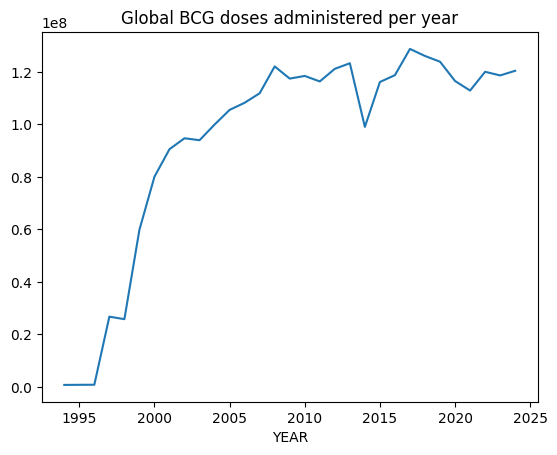

In [11]:
df.groupby('YEAR')['DOSES'].sum().plot(title='Global BCG doses administered per year')


## Country Analysis

<Axes: title={'center': 'Top 10 countries by total doses'}, ylabel='NAME'>

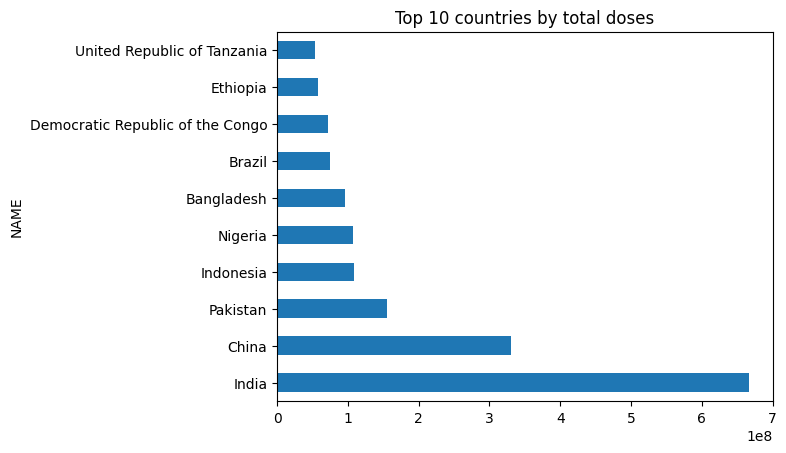

In [13]:
df.groupby('NAME')['DOSES'].sum().nlargest(10).plot(kind='barh', title='Top 10 countries by total doses')


In [12]:
df.groupby('CODE')['YEAR'].agg(['min', 'max', 'count']).sort_values(by='count')

,min,max,count
CODE,,,
ITA,2020,2020,1
PYF,2022,2022,1
AUS,2024,2024,1
GRD,2015,2015,1
SVN,2001,2001,1
...,...,...,...
ZWE,1999,2024,26
IND,1997,2024,27
VEN,1997,2024,28


In [14]:
years_per_country = df.groupby('CODE')['YEAR'].count()
years_per_country.describe()


count    185.000000
mean      21.616216
std        7.048647
min        1.000000
25%       23.000000
50%       24.000000
75%       26.000000
max       31.000000
Name: YEAR, dtype: float64

In [15]:
years_per_country = df.groupby('CODE')['YEAR'].count()
countries_to_keep = years_per_country[years_per_country >= 5].index

df = df[df['CODE'].isin(countries_to_keep)].reset_index(drop=True)

print(f"Countries removed: {(years_per_country < 5).sum()}")
print(f"Countries kept:    {len(countries_to_keep)}")


Countries removed: 12
Countries kept:    173


In [16]:
df.groupby('CODE')['YEAR'].apply(
    lambda y: y.sort_values().diff().max()
).sort_values(ascending=False).head(20)

CODE
CZE    18.0
THA    16.0
MSR    14.0
AIA    14.0
TCA    14.0
CYM    14.0
PSE    10.0
WLF     7.0
ARE     7.0
BRB     6.0
HKG     4.0
JPN     4.0
DZA     4.0
MYS     4.0
CRI     3.0
COK     3.0
LBY     3.0
KWT     3.0
ISL     3.0
SEN     3.0
Name: YEAR, dtype: float64

Gaps will be handled via forward-fill or linear interpolation during feature engineering, and countries with gaps >5 years will be flagged.Flagging will happen during feature engineering, not here

## Distribution & Outliers

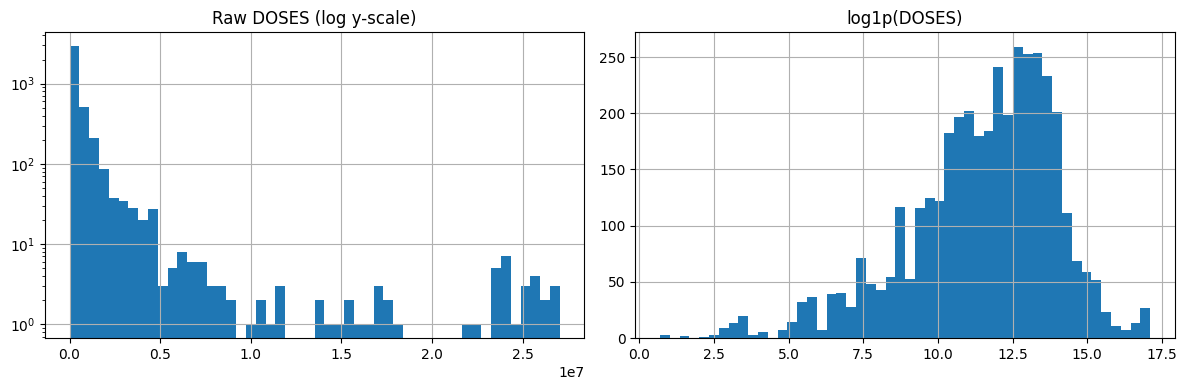

In [26]:
# Histogram of DOSES (log scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['DOSES'].hist(bins=50, log=True, ax=axes[0])
axes[0].set_title('Raw DOSES (log y-scale)')
df['DOSES'].apply('log1p').hist(bins=50, ax=axes[1])
axes[1].set_title('log1p(DOSES)')
plt.tight_layout()


In [18]:
#Zero-dose rows — flag or drop decision
df[df['DOSES'] == 0]

,CODE,NAME,YEAR,DOSES
1355,ISL,Iceland,2016,0
1669,ISL,Iceland,2014,0
2134,ISL,Iceland,2011,0
2288,ISL,Iceland,2010,0
2443,ISL,Iceland,2009,0
2902,ISL,Iceland,2006,0
3644,JOR,Jordan,2001,0


In [19]:
df = df[df['DOSES'] != 0]
df.reset_index(drop=True, inplace=True)

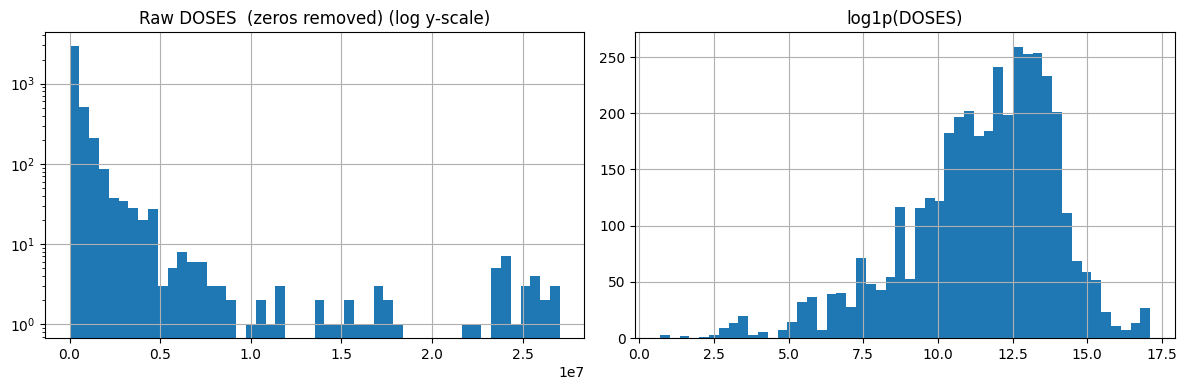

In [27]:
# Histogram of DOSES (log scale)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['DOSES'].hist(bins=50, log=True, ax=axes[0])
axes[0].set_title('Raw DOSES  (zeros removed) (log y-scale)')
df['DOSES'].apply('log1p').hist(bins=50, ax=axes[1])
axes[1].set_title('log1p(DOSES) (zeros removed)')
plt.tight_layout()


In [21]:
# extreme outliers
df[df['DOSES'] > df['DOSES'].quantile(0.99)]

,CODE,NAME,YEAR,DOSES
66,IND,India,2024,23750802
230,IND,India,2023,23697675
391,IND,India,2022,24120021
548,IND,India,2021,22076212
706,IND,India,2020,22477254
826,CHN,China,2019,14459250
862,IND,India,2019,24203618
989,CHN,China,2018,15114102
1025,IND,India,2018,23461701
1155,CHN,China,2017,17404506


India and China are legitimate high-volume countries, not errors and this data will be kept as they are legitimate data points and should be given special attention when looking at those numbers

## Completeness Heatmap

<Axes: xlabel='YEAR', ylabel='CODE'>

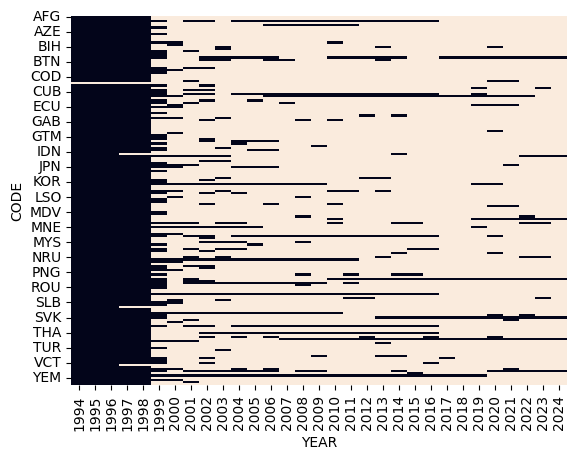

In [22]:
pivot = df.pivot_table(index='CODE', columns='YEAR', values='DOSES', aggfunc='sum')
sns.heatmap(pivot.notna(), cbar=False)       # presence/absence map

## Save Cleaned Data

In [ ]:
df.describe()

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3968 entries, 0 to 3967
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   CODE    3968 non-null   str  
 1   NAME    3968 non-null   str  
 2   YEAR    3968 non-null   int64
 3   DOSES   3968 non-null   int64
dtypes: int64(2), str(2)
memory usage: 176.7 KB


In [24]:
df.to_parquet('../../data/processed/bcg_doses_clean.parquet', index=False)